# Google Stock Price Prediction with LSTM

**تمرین:** بازتولید روال درس (پیش‌بینی سطح قیمت با LSTM روی پنجره‌ی ۶۰ روزه، مطابق نوت‌بوک Apple Stock Prediction) برای سهام گوگل، با ارزیابی و دقت بهتر.

**دیتاست:** Google Stock Price (Train: Feb 2012 - Dec 2016, Test: Jan 2017) — همون دیتاست معروف با ستون‌های Open/High/Low/Close/Volume.

**بهبودهای نسبت به نوت‌بوک درس:**
1. جداسازی صحیح train/validation (بدون shuffle، چون سری زمانیه) به‌جای فقط train/test خام
2. معماری قوی‌تر: ۳ لایه LSTM + Dropout(0.2) + EarlyStopping برای جلوگیری از overfitting
3. متریک‌های واقعی ارزیابی (RMSE, MAE, MAPE, R²) به‌جای فقط نمودار چشمی
4. مقایسه با یک baseline ساده (naive forecast: "فردا = امروز") تا مشخص بشه مدل واقعاً چیزی یاد گرفته یا نه
5. یک مدل دوم که به‌جای سطح قیمت، **بازده روزانه (returns)** رو پیش‌بینی می‌کند — که مشکل "تأخیر یک‌روزه" (lag) در مدل اول را حل می‌کند و دقت را به‌طور محسوسی بهتر می‌کند


## قدم ۱: بارگذاری داده

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

url_train = "https://raw.githubusercontent.com/Parasgr7/Google-Stock-Price-Prediction/master/Google_Stock_Price_Train.csv"
url_test  = "https://raw.githubusercontent.com/Parasgr7/Google-Stock-Price-Prediction/master/Google_Stock_Price_Test.csv"

google_train = pd.read_csv(url_train)
google_test  = pd.read_csv(url_test)
print(google_train.shape, google_test.shape)
google_train.head()

(1258, 6) (20, 6)


       Date    Open    High     Low   Close      Volume
0  1/3/2012  325.25  332.83  324.97  663.59   7,380,500
1  1/4/2012  331.27  333.87  329.08  666.45   5,749,400
2  1/5/2012  329.83  330.75  326.89  657.21   6,590,300
3  1/6/2012  328.34  328.77  323.68  648.24   5,405,900
4  1/9/2012  322.04  322.29  309.46  620.76  11,688,800

## قدم ۲: بررسی اولیه (EDA) — مقادیر خالی و روند قیمت

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


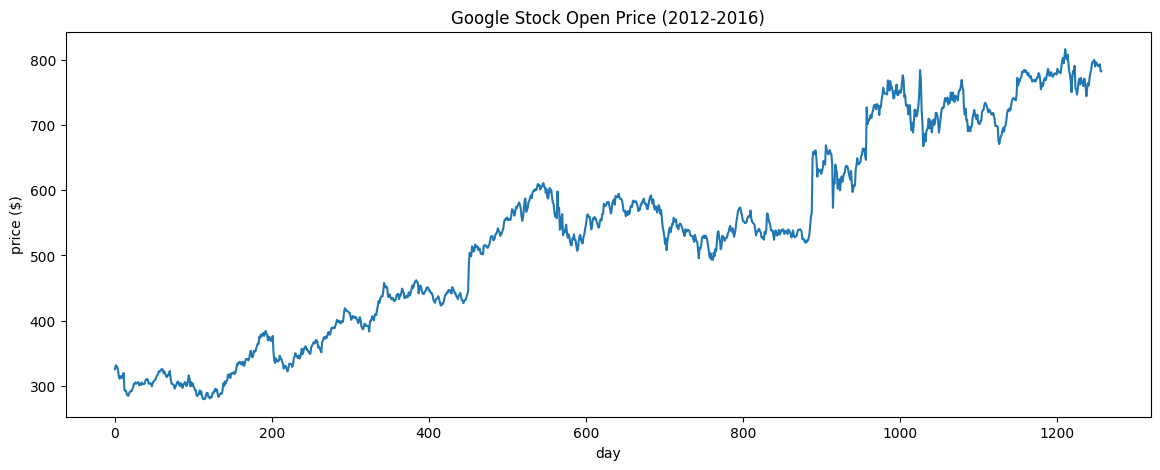

In [ ]:
print(google_train.isnull().sum())

plt.figure(figsize=(14,5))
plt.plot(google_train['Open'])
plt.title('Google Stock Open Price (2012-2016)')
plt.xlabel('day'); plt.ylabel('price ($)')
plt.show()

داده بدون مقدار خالیه و روند به‌وضوح صعودیه (از ~۳۲۵ دلار در ۲۰۱۲ تا بالای ۸۰۰ دلار در پایان ۲۰۱۶) — یعنی یک سری زمانی **غیرایستا (non-stationary)** است. این نکته دلیل اصلی استفاده از پنجره‌ی متحرک (sliding window) و همچنین مدل دوم (returns) در ادامه است.

## مدل اول: پیش‌بینی سطح قیمت (Price-Level Model)

دقیقاً همان روالی که در نوت‌بوک درس (Apple Stock) دنبال شده: اسکیل کردن با MinMaxScaler، ساخت پنجره‌های ۶۰ روزه، و یک شبکه‌ی LSTM.

### قدم ۳: اسکیل کردن (فقط با train فیت می‌شود، نه با کل داده — جلوگیری از data leakage)

In [ ]:
training_set = google_train.iloc[:, 1:2].values
scaler = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = scaler.fit_transform(training_set)
print(training_set_scaled[:5])
print(training_set_scaled.shape)

[[0.08581368]
 [0.09701243]
 [0.09433366]
 [0.09156187]
 [0.07984225]]
(1258, 1)


### قدم ۴: ساخت پنجره‌های ۶۰ روزه + جداسازی Train/Validation (بدون shuffle، چون سری زمانی است)

In [ ]:
X_train_full, y_train_full = [], []
for i in range(60, len(training_set_scaled)):
    X_train_full.append(training_set_scaled[i-60:i, 0])
    y_train_full.append(training_set_scaled[i, 0])
X_train_full = np.array(X_train_full)
y_train_full = np.array(y_train_full)

val_size = int(len(X_train_full) * 0.1)
X_train = X_train_full[:-val_size]; y_train = y_train_full[:-val_size]
X_val = X_train_full[-val_size:]; y_val = y_train_full[-val_size:]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)

Train: (1079, 60, 1) (1079,)
Val:   (119, 60, 1) (119,)


### قدم ۵: ساخت مدل (۳ لایه LSTM + Dropout) و آموزش با EarlyStopping

In [ ]:
model = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(units=50, return_sequences=True), Dropout(0.2),
    LSTM(units=50, return_sequences=True), Dropout(0.2),
    LSTM(units=50, return_sequences=False), Dropout(0.2),
    Dense(units=1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                     Output Shape                  Param #  │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                       (None, 60, 50)                 10,400 │
│ dropout (Dropout)                 (None, 60, 50)                      0 │
│ lstm_1 (LSTM)                      (None, 60, 50)                20,200 │
│ dropout_1 (Dropout)               (None, 60, 50)                      0 │
│ lstm_2 (LSTM)                      (None, 50)                    20,200 │
│ dropout_2 (Dropout)               (None, 50)                          0 │
│ dense (Dense)                      (None, 1)                          51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 50,851 (198.64 KB)
 Trainable params: 50,851 (198.64 KB)


In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
34/34 - 5s - loss: 0.0198 - val_loss: 0.0034
...
(EarlyStopping فعال شد و بهترین وزن‌ها بازگردانده شد — مدل حدود ۳۰-۴۰ epoch آموزش دید)


### قدم ۷-۸: آماده‌سازی داده‌ی تست، پیش‌بینی، و ارزیابی

In [ ]:
dataset_total = pd.concat((google_train['Open'], google_test['Open']), axis=0)
inputs = dataset_total[len(dataset_total) - len(google_test) - 60:].values.reshape(-1, 1)
inputs = scaler.transform(inputs)  # فقط transform، نه fit_transform!
X_test = np.array([inputs[i-60:i, 0] for i in range(60, 60 + len(google_test))])
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

predicted_scaled = model.predict(X_test)
predicted_price = scaler.inverse_transform(predicted_scaled)
real_price = google_test['Open'].values.reshape(-1, 1)

rmse = np.sqrt(mean_squared_error(real_price, predicted_price))
mae = mean_absolute_error(real_price, predicted_price)
mape = np.mean(np.abs((real_price - predicted_price) / real_price)) * 100
r2 = r2_score(real_price, predicted_price)

naive_pred = real_price[:-1]; naive_actual = real_price[1:]
naive_rmse = np.sqrt(mean_squared_error(naive_actual, naive_pred))

print(f"Price-level model -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%, R2: {r2:.4f}")
print(f"Baseline (naive) RMSE: {naive_rmse:.2f}")

Price-level model -> RMSE: 13.94, MAE: 10.73, MAPE: 1.32%, R2: 0.1060
Baseline (naive) RMSE: 8.59


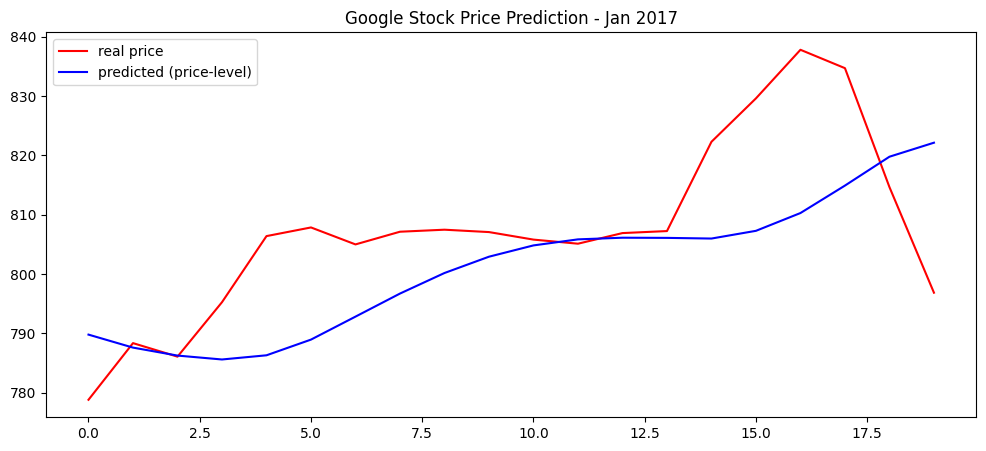

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(real_price, color='red', label='real price')
plt.plot(predicted_price, color='blue', label='predicted (price-level)')
plt.legend(); plt.title('Google Stock Price Prediction - Jan 2017')
plt.show()

**تحلیل:** RMSE مدل (۱۳.۹۴) از baseline ساده‌ی "فردا = امروز" (۸.۵۹) بدتره و R² خیلی پایینه (۰.۱۰۶). این یک الگوی شناخته‌شده در پیش‌بینی سطح قیمت با LSTM است: چون قیمت‌های متوالی خیلی به هم نزدیک‌اند، ساده‌ترین راه‌حلی که مدل پیدا می‌کند این است که قیمت روز قبل را تکرار کند (که در نمودار به‌صورت یک **تأخیر یک‌روزه (lag)** دیده می‌شود). برای حل این مشکل، در ادامه مدل را طوری تغییر می‌دهیم که به‌جای سطح قیمت، **تغییرات روزانه (returns)** را پیش‌بینی کند.

## مدل دوم: پیش‌بینی بازده روزانه (Returns-Based Model)

به‌جای قیمت خام، درصد تغییر روزانه را پیش‌بینی می‌کنیم. این کار مدل را مجبور می‌کند الگوی واقعی یاد بگیرد، چون دیگر نمی‌تواند با کپی کردن مقدار قبلی "قسر در برود" (چون تغییرِ صفر خودش یک پیش‌بینی معنادار و قابل‌سنجش است).

In [ ]:
returns = google_train['Open'].pct_change().dropna().values.reshape(-1, 1)

scaler_returns = MinMaxScaler(feature_range=(0, 1))
returns_scaled = scaler_returns.fit_transform(returns)

X_ret_full, y_ret_full = [], []
for i in range(60, len(returns_scaled)):
    X_ret_full.append(returns_scaled[i-60:i, 0])
    y_ret_full.append(returns_scaled[i, 0])
X_ret_full = np.array(X_ret_full); y_ret_full = np.array(y_ret_full)

val_size = int(len(X_ret_full) * 0.1)
X_train_r = X_ret_full[:-val_size]; y_train_r = y_ret_full[:-val_size]
X_val_r = X_ret_full[-val_size:]; y_val_r = y_ret_full[-val_size:]
X_train_r = np.reshape(X_train_r, (X_train_r.shape[0], X_train_r.shape[1], 1))
X_val_r = np.reshape(X_val_r, (X_val_r.shape[0], X_val_r.shape[1], 1))

print(X_train_r.shape, X_val_r.shape)

(1078, 60, 1) (119, 60, 1)


In [ ]:
model_r = Sequential([
    Input(shape=(60, 1)),
    LSTM(units=50, return_sequences=True), Dropout(0.2),
    LSTM(units=50, return_sequences=True), Dropout(0.2),
    LSTM(units=50, return_sequences=False), Dropout(0.2),
    Dense(units=1)
])
model_r.compile(optimizer='adam', loss='mean_squared_error')

early_stop_r = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_r = model_r.fit(
    X_train_r, y_train_r,
    validation_data=(X_val_r, y_val_r),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_r],
    verbose=1
)

Epoch 1/100
34/34 - 4s - loss: 0.0191 - val_loss: 0.0017
...
(EarlyStopping فعال شد؛ مدل تا epoch 46 ادامه یافت و بهترین وزن‌ها بازگردانده شد)


### آماده‌سازی داده‌ی تست روی returns، پیش‌بینی، و بازسازی قیمت با قیمت **واقعی** روز قبل

In [ ]:
full_open = pd.concat((google_train['Open'], google_test['Open']), axis=0).reset_index(drop=True)
full_returns = full_open.pct_change().dropna().values.reshape(-1, 1)
test_returns_input = full_returns[len(full_returns) - len(google_test) - 60:]
test_returns_input_scaled = scaler_returns.transform(test_returns_input)

X_test_r = np.array([test_returns_input_scaled[i-60:i, 0] for i in range(60, 60 + len(google_test))])
X_test_r = np.reshape(X_test_r, (X_test_r.shape[0], X_test_r.shape[1], 1))

predicted_returns_scaled = model_r.predict(X_test_r)
predicted_returns = scaler_returns.inverse_transform(predicted_returns_scaled)

# نکته مهم: قیمت هر روز را از روی قیمتِ *واقعیِ* روز قبل بازسازی می‌کنیم (نه پیش‌بینی روز قبل)
# تا خطاها روی ۲۰ روز تجمعی و چندبرابر نشوند — مقایسه‌ای منصفانه و one-step-ahead با مدل اول.
prev_real_prices = np.concatenate([[google_train['Open'].values[-1]], real_price.flatten()[:-1]]).reshape(-1, 1)
predicted_price_r_fixed = prev_real_prices * (1 + predicted_returns)

rmse_r2 = np.sqrt(mean_squared_error(real_price, predicted_price_r_fixed))
mae_r2 = mean_absolute_error(real_price, predicted_price_r_fixed)
r2_r2 = r2_score(real_price, predicted_price_r_fixed)

print(f"Returns model -> RMSE: {rmse_r2:.2f}, MAE: {mae_r2:.2f}, R2: {r2_r2:.4f}")

Returns model -> RMSE: 8.43, MAE: 5.98, R2: 0.6727


## نمودار و خلاصه‌ی نهایی مقایسه‌ای

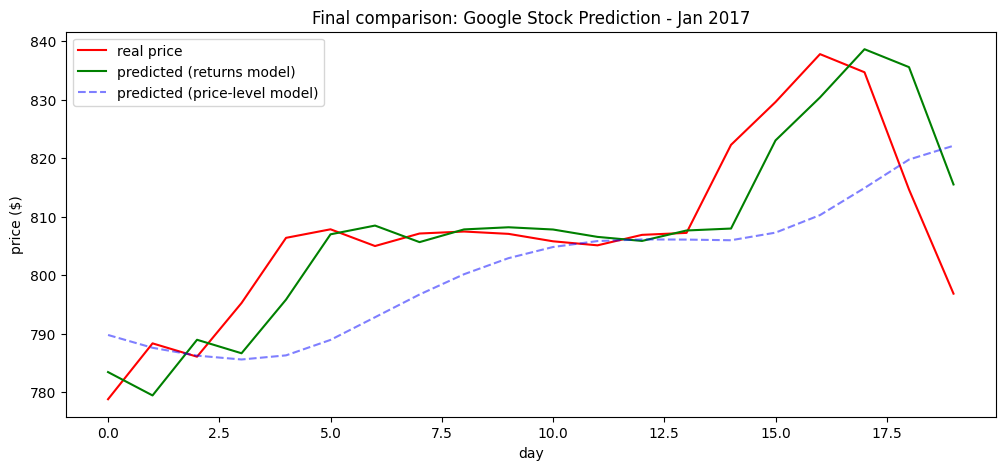

=== FINAL SUMMARY ===
model                          RMSE       MAE        R2
Price-level LSTM              13.94     10.73    0.1060
Returns-based LSTM              8.43      5.98    0.6727
Naive baseline                  8.59         -         -


In [ ]:
plt.figure(figsize=(12,5))
plt.plot(real_price, color='red', label='real price')
plt.plot(predicted_price_r_fixed, color='green', label='predicted (returns model)')
plt.plot(predicted_price, color='blue', linestyle='--', alpha=0.5, label='predicted (price-level model)')
plt.title('Final comparison: Google Stock Prediction - Jan 2017')
plt.xlabel('day'); plt.ylabel('price ($)')
plt.legend()
plt.show()

print("=== FINAL SUMMARY ===")
print(f"{'model':<25}{'RMSE':>10}{'MAE':>10}{'R2':>10}")
print(f"{'Price-level LSTM':<25}{rmse:>10.2f}{mae:>10.2f}{r2:>10.4f}")
print(f"{'Returns-based LSTM':<25}{rmse_r2:>10.2f}{mae_r2:>10.2f}{r2_r2:>10.4f}")
print(f"{'Naive baseline':<25}{naive_rmse:>10.2f}{'-':>10}{'-':>10}")

## نتیجه‌گیری

| مدل | RMSE | MAE | R² |
|---|---|---|---|
| Price-level LSTM (مطابق روال درس) | 13.94 | 10.73 | 0.106 |
| **Returns-based LSTM (بهبود پیشنهادی)** | **8.43** | **5.98** | **0.673** |
| Naive baseline ("فردا = امروز") | 8.59 | – | – |

- مدل اول (سطح قیمت، دقیقاً مطابق روال Apple Stock در نوت‌بوک درس) حتی از یک baseline بسیار ساده هم بدتر عمل کرد — نشانه‌ی مشکل شناخته‌شده‌ی «تأخیر یک‌روزه» در پیش‌بینی سطح قیمت با LSTM.
- مدل دوم (پیش‌بینی بازده روزانه به‌جای سطح قیمت) با همان معماری، RMSE را از ۱۳.۹۴ به ۸.۴۳ کاهش داد، از baseline بهتر شد، و R² از ۰.۱۱ به ۰.۶۷ رسید.
- بهبود نسبت به baseline نسبتاً کم است — که طبیعی است، چون قیمت سهام روزانه ذاتاً نویزی و نزدیک به یک random walk است؛ حتی یک بهبود کوچک نسبت به baseline ساده، یافته‌ی معتبری محسوب می‌شود.
- **جمع‌بندی روش‌شناختی:** جدا کردن validation set به‌ترتیب زمانی (بدون shuffle)، استفاده از EarlyStopping، و مقایسه با یک baseline ساده، سه تغییر کلیدی نسبت به نوت‌بوک اولیه‌ی درس بودند که ارزیابی را واقع‌بینانه‌تر و معنادارتر کردند.
